In [5]:
import os
os.environ["XDG_CACHE_HOME"] = "/ceph/hpc/home/ciangottinid/.cache"
import skimage

In [6]:
from tqdm import tqdm
import torch
import numpy as np
import xarray as xr
from skimage.metrics import structural_similarity as ssim
from scipy.stats import entropy
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

from Fires._utilities.metrics import WeightedBCE_L1Loss
from Fires._utilities.utils_mlflow import load_model_from_mlflow

from Fires._utilities.utils_inference import compute_aggregated_mape_smape,load_input_data, create_data_loader, process_and_plot_data, get_prov_image

In [8]:
run_name=input()
registered_model = load_model_from_mlflow(run_name, provenance=True)
registered_model 

 lastone


Data from MLFlow downloaded in: /jupyter-workspace/persistent-storage/ML4Fires/MLFLOW/lastone


UnetPlusPlus(
  (activation): Sigmoid()
  (pool_2x2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (pool_3x3): MaxPool2d(kernel_size=(3, 3), stride=(3, 3), padding=0, dilation=1, ceil_mode=False)
  (up_2x2): Upsample(scale_factor=(2.0, 2.0), mode='bilinear')
  (up_3x3): Upsample(scale_factor=(3.0, 3.0), mode='bilinear')
  (conv0_0): VGGBlock(
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv1_0): VGGBlock(
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Co

In [9]:
# define path to complete dataset
data_path = "/ceph/hpc/home/ciangottinid/ML4Fires/data/ML4Fires_copy/data_100km.zarr"

input_data = load_input_data(data_path, '2019', '2020')
input_data

['lai', 'rel_hum', 't2m_min', 'tp', 'lsm'] 
 ['fcci_ba']
(180, 360)


<xarray.Dataset> Size: 167MB
Dimensions:    (time: 92, latitude: 180, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * time       (time) datetime64[ns] 736B 2019-01-01 2019-01-09 ... 2020-12-26
Data variables:
    lai        (time, latitude, longitude) float32 24MB nan nan nan ... nan nan
    rel_hum    (time, latitude, longitude) float32 24MB 89.11 89.19 ... 61.39
    t2m_min    (time, latitude, longitude) float32 24MB 246.2 246.2 ... 242.5
    tp         (time, latitude, longitude) float32 24MB 1.802 1.802 ... 0.3219
    lsm        (time, latitude, longitude) float32 24MB 0.0 0.0 0.0 ... 1.0 1.0
    fcci_ba    (time, latitude, longitude) float64 48MB nan nan nan ... 0.0 0.0
Attributes:
    crs:          EPSG:4326
    description:  The SeasFire Cube is a scientific datacube for seasonal fir...
    title:        SeasFire Cube: A Global Dataset for Seasonal Fire Modeling ...

In [10]:
torch_data_loader = create_data_loader(data_path, run_name)

In [11]:
preds = []
with torch.no_grad():
	for data, _ in tqdm(torch_data_loader):
		prediction = registered_model(data.to('cuda:0'))
		prediction_cpu = prediction.cpu().numpy()
		preds.append(prediction_cpu)
preds_array = np.vstack(preds)

100%|██████████| 92/92 [00:02<00:00, 39.14it/s]


Is DataArray - AVG: (180, 360) STD: (180, 360)
 Mean of data: (180, 360)
 Max: 5135.48 	 Min: 0.0
 Lats Max: 1027.5 	 Lons Max: 539.6
 Mean of data: (180, 360)
 Max: 13253.32 	 Min: 0.0
 Lats Max: 1883.89 	 Lons Max: 1051.82


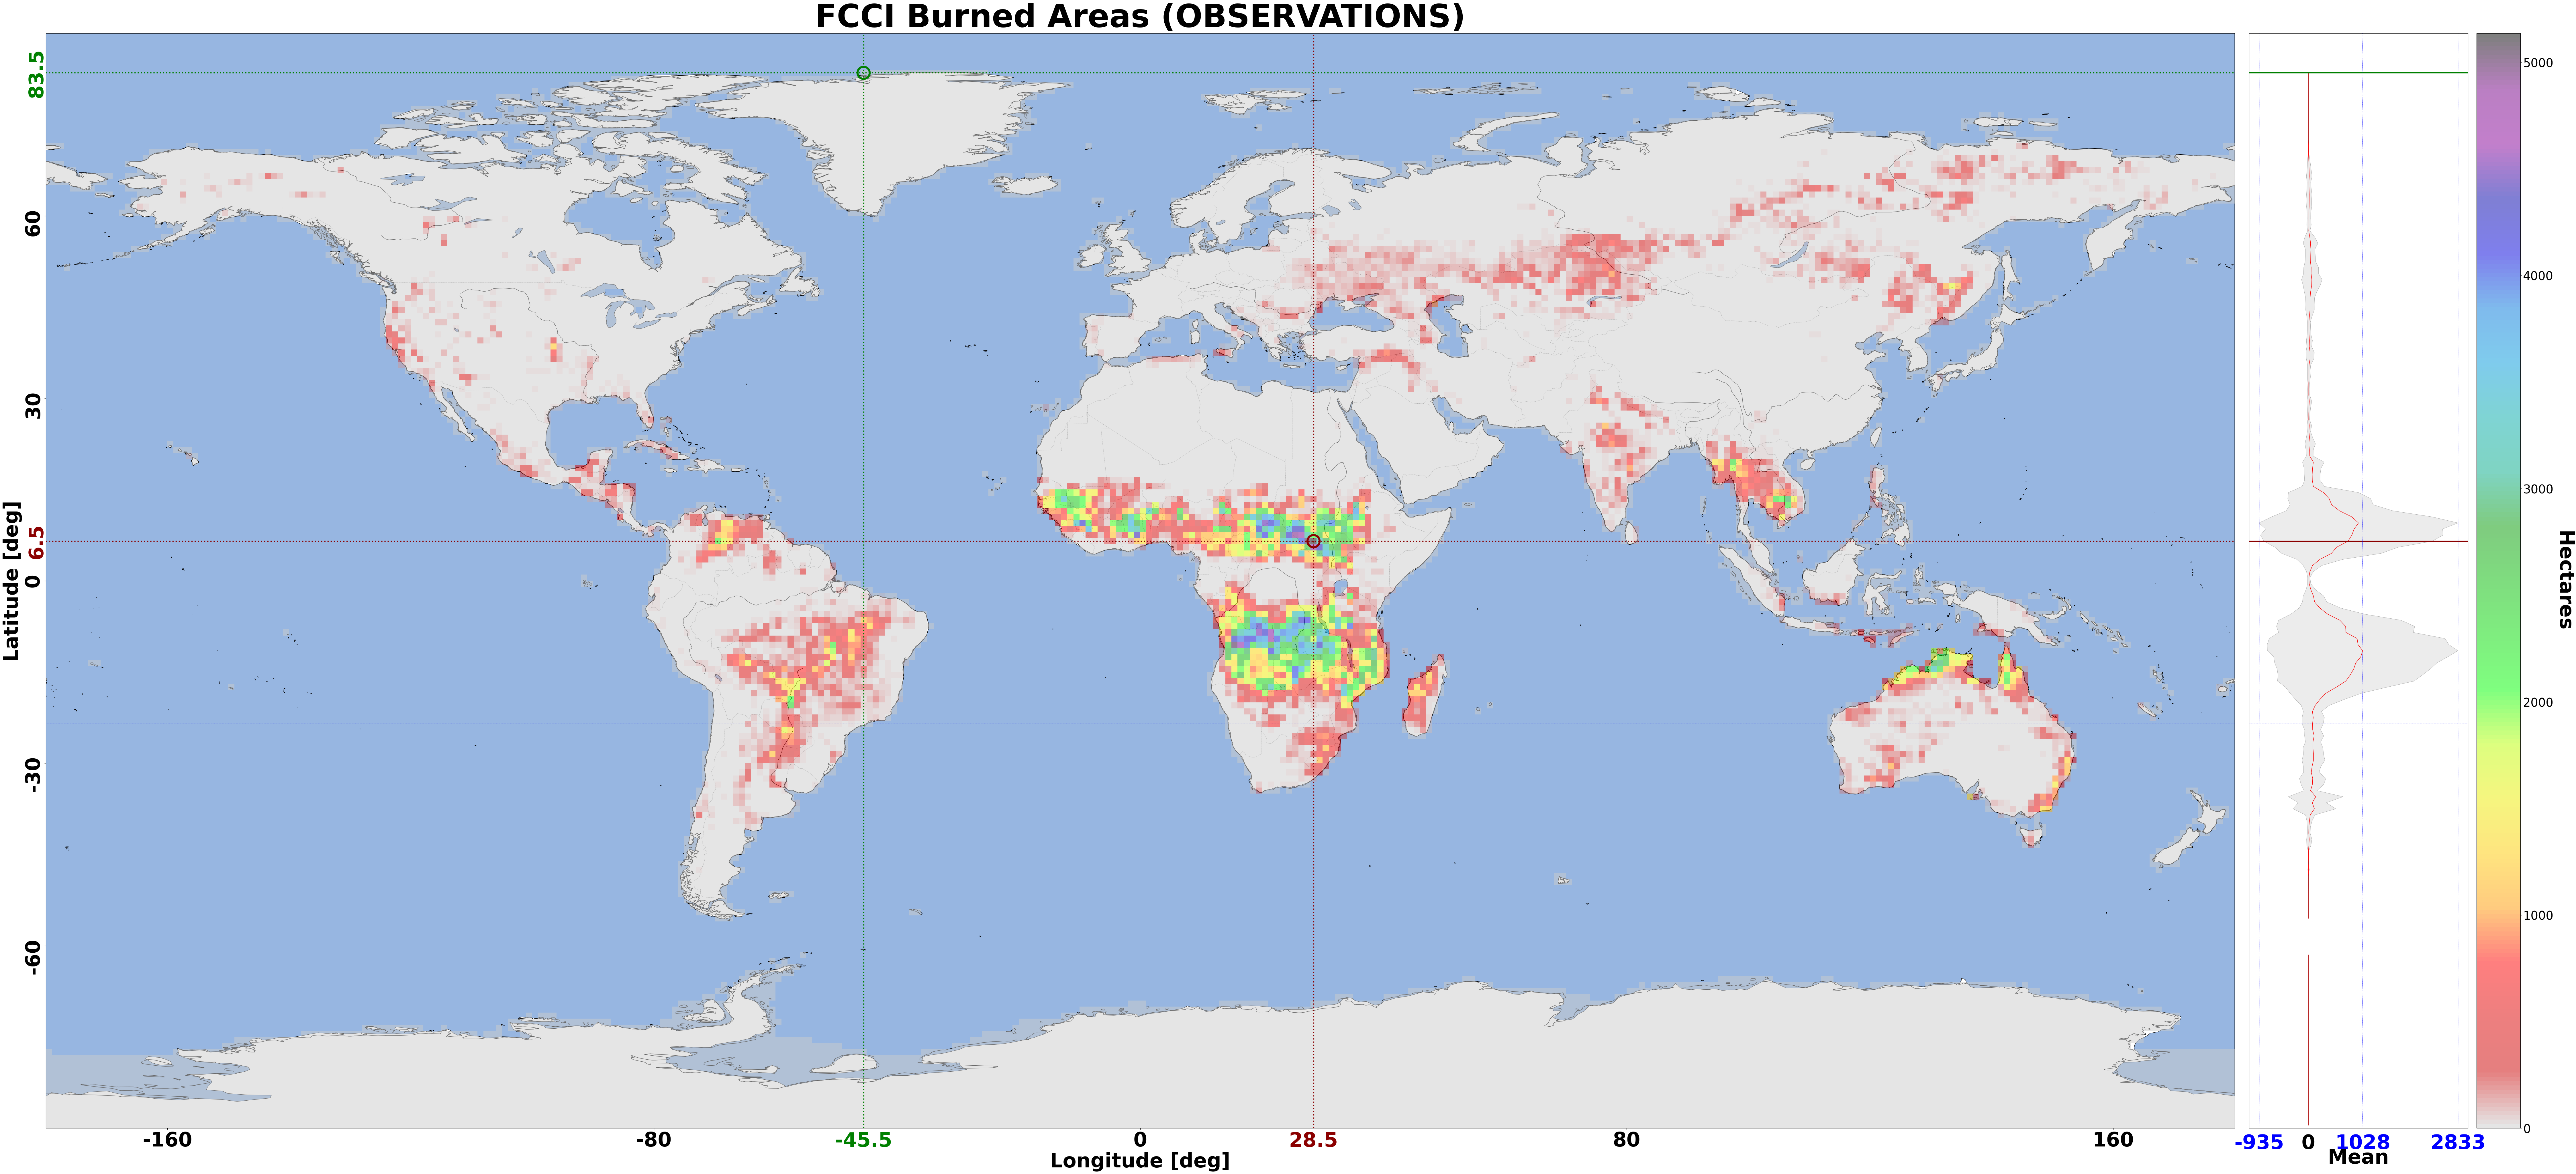

In [7]:
process_and_plot_data(
	data=input_data.fcci_ba,
	label='FCCI Burned Areas',
	lats=input_data.latitude.values,
	lons=input_data.longitude.values,
	model_name="Observations"
)

NOT DataArray - AVG: (180, 360) STD: (180, 360)
 Mean of data: (180, 360)
 Max: 5644.52001953125 	 Min: 0.0
 Lats Max: 1013.97998046875 	 Lons Max: 583.719970703125
 Mean of data: (180, 360)
 Max: 12181.0400390625 	 Min: 0.0
 Lats Max: 1920.52001953125 	 Lons Max: 1009.3300170898438


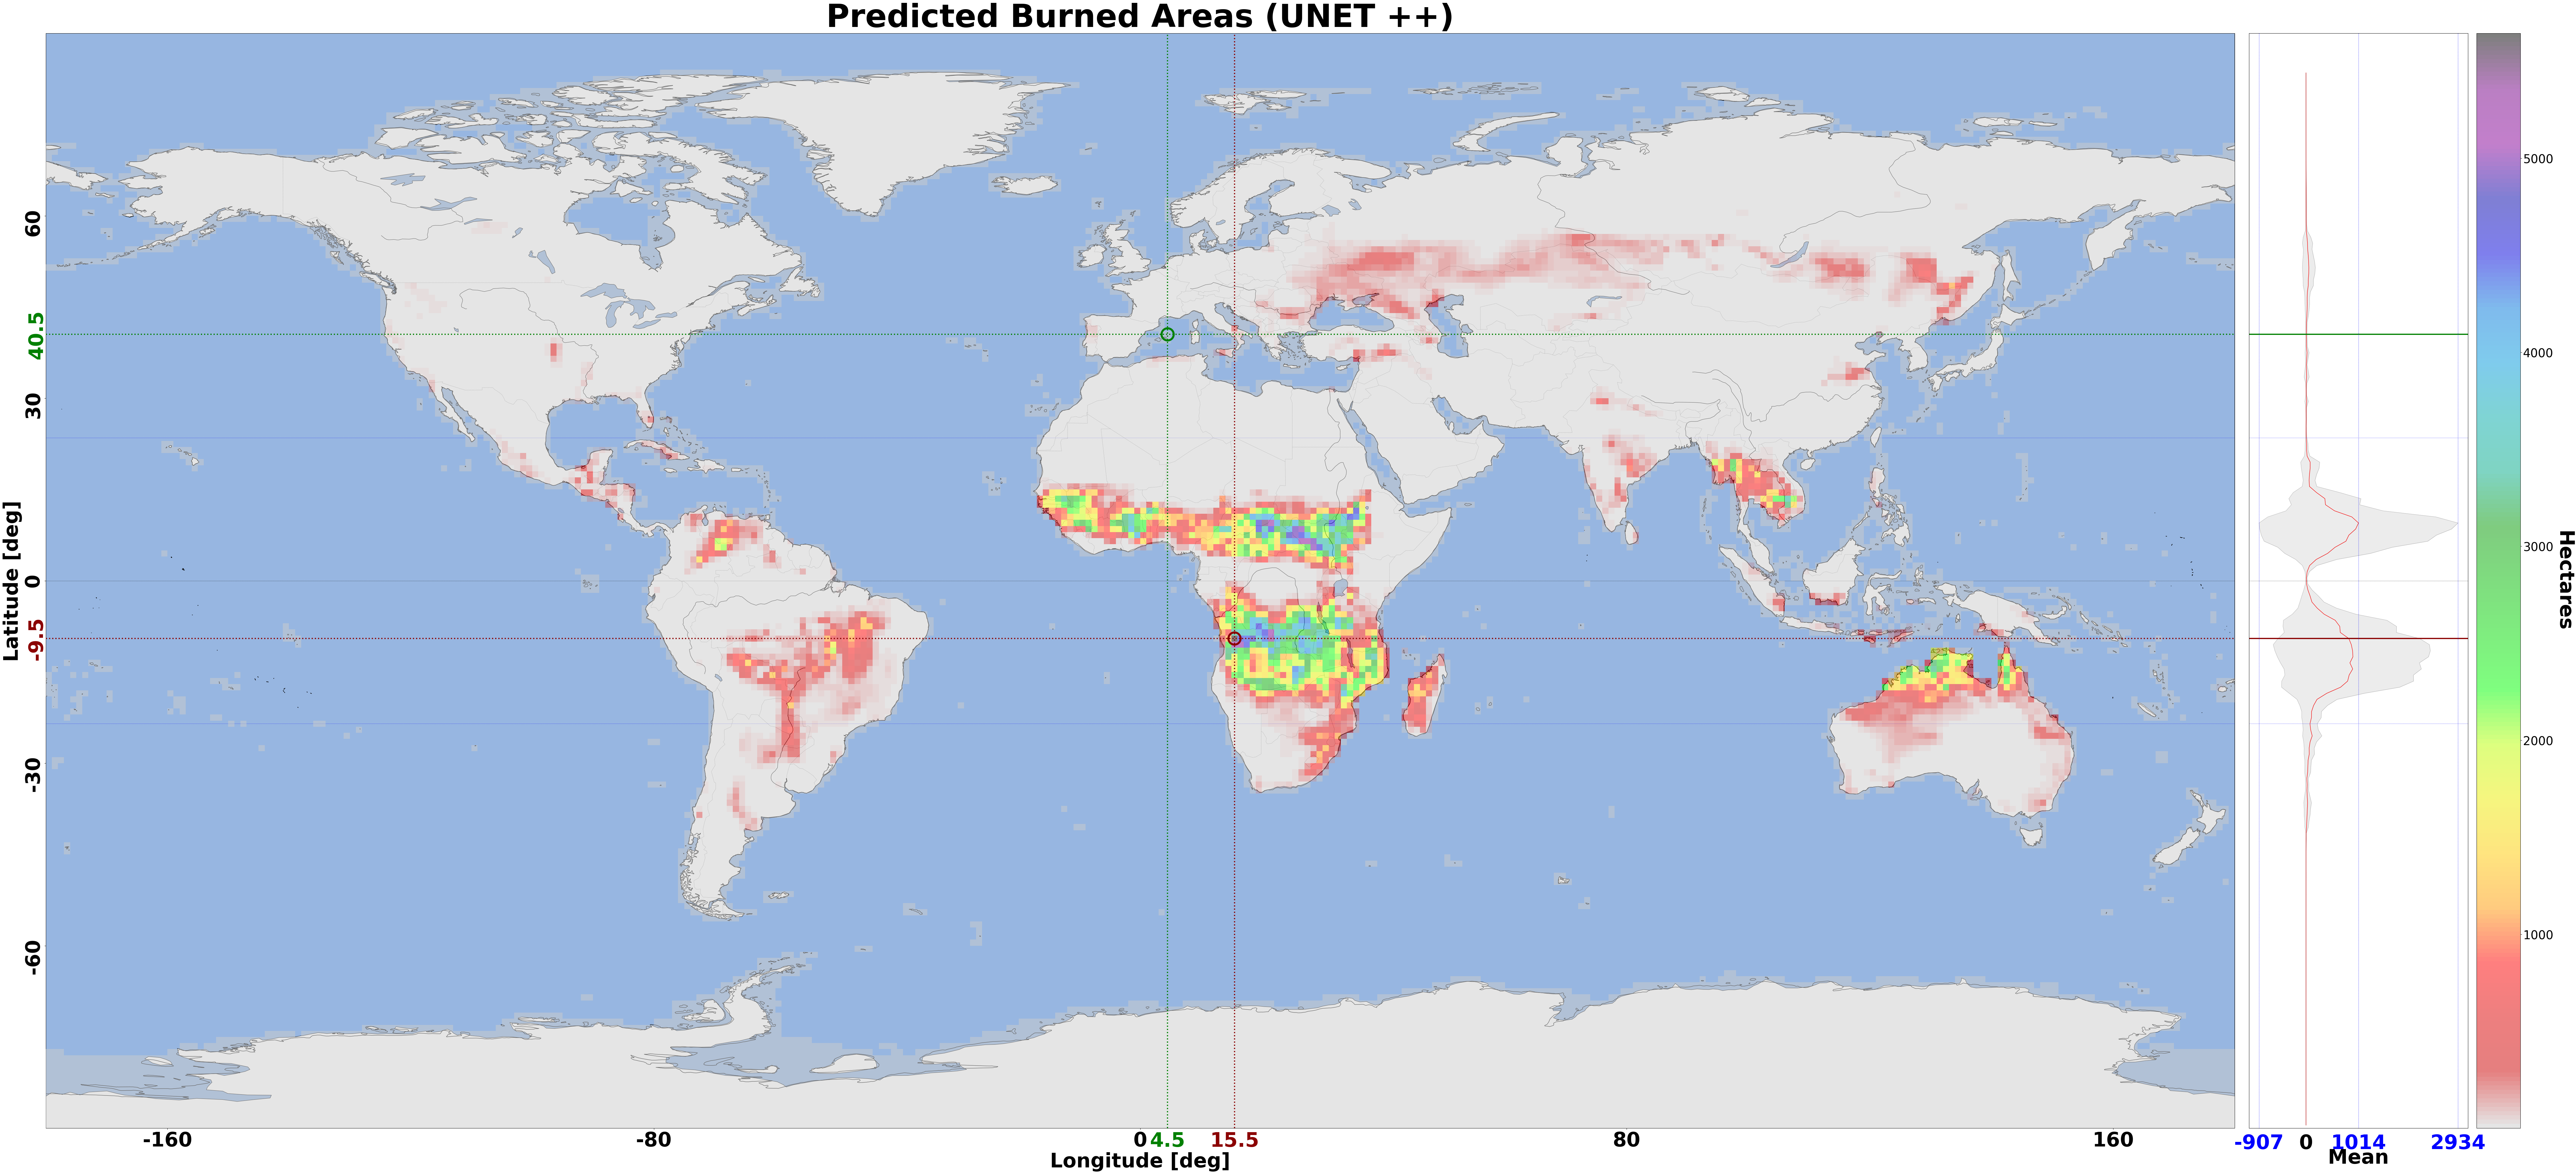

In [8]:
process_and_plot_data(
	data=preds_array,
	label='Predicted Burned Areas',
	lats=input_data.latitude.values,
	lons=input_data.longitude.values,
	model_name="Unet ++"
)

In [12]:
def compute_mse(input_tensor, preds_tensor):
    return torch.mean((input_tensor - preds_tensor) ** 2).item()

def compute_ssim(input_tensor, preds_tensor):
    return ssim(input_tensor.numpy(), preds_tensor.numpy(), data_range=preds_tensor.max().item() - preds_tensor.min().item())

def compute_kl_divergence(input_tensor, preds_tensor):
    """Compute Kullback-Leibler (KL) Divergence to measure the difference in probability distributions."""
    eps = 1e-10  # Small constant to prevent division by zero
    
    # Normalize probabilities correctly
    input_prob = (input_tensor + eps) / ((input_tensor + eps).sum())
    preds_prob = (preds_tensor + eps) / ((preds_tensor + eps).sum())

    # Avoid log(0) errors by ensuring all values are in a valid probability range
    input_prob = torch.clamp(input_prob, min=eps, max=1.0)
    preds_prob = torch.clamp(preds_prob, min=eps, max=1.0)

    # Compute KL divergence
    kl_div = entropy(input_prob.flatten().numpy(), preds_prob.flatten().numpy())

    return kl_div

def compute_iou(input_binary, preds_binary):
    intersection = torch.logical_and(input_binary, preds_binary).sum().item()
    union = torch.logical_or(input_binary, preds_binary).sum().item()
    return intersection / union if union != 0 else 0

def compute_f1_score(input_binary, preds_binary):
    input_flat = input_binary.flatten().numpy()
    preds_flat = preds_binary.flatten().numpy()
    precision, recall, f1_score, _ = precision_recall_fscore_support(input_flat, preds_flat, average='binary', zero_division=0)
    return precision, recall, f1_score

def compute_dice_coefficient(input_binary, preds_binary):
    """Compute Sørensen–Dice coefficient between predicted and actual burned area maps."""
    intersection = torch.logical_and(input_binary, preds_binary).sum().item()
    total_pixels = input_binary.sum().item() + preds_binary.sum().item()
    dice_score = (2 * intersection) / total_pixels if total_pixels != 0 else 0.0
    return dice_score

def compute_ioa(y_true, y_pred, c=2):
    """Compute the Index of Agreement (IOA)"""
    y_mean = torch.mean(y_true)
    numerator = torch.sum(torch.abs(y_pred - y_true))
    denominator = torch.sum(torch.abs(y_true - y_mean))
    
    if numerator <= denominator:
        ioa = 1 - (numerator / (c * denominator))
    else:
        ioa = (c * denominator) / numerator - 1
    
    return ioa.item()

def compute_r2(y_true, y_pred):
    """Compute the Coefficient of Determination (R²)"""
    y_mean = torch.mean(y_true)
    ss_total = torch.sum((y_true - y_mean) ** 2)
    ss_residual = torch.sum((y_true - y_pred) ** 2)
    
    r2 = 1 - (ss_residual / ss_total)
    return r2.item()

def compute_rmse(y_true, y_pred):
    """Compute the Root Mean Squared Error (RMSE)"""
    rmse = torch.sqrt(torch.mean((y_true - y_pred) ** 2))
    return rmse.item()

def compute_mae(y_true, y_pred):
    """Compute Mean Absolute Error (MAE) for burned area percentage prediction."""
    return torch.mean(torch.abs(y_true - y_pred)).item()


def find_best_threshold(input_tensor, preds_tensor, thresholds=[1e-6, 1e-5, 1e-4, 1e-3,1e-2,1e-1,0.01]):
    best_threshold = None
    best_f1 = 0
    best_metrics = None
    
    for t in thresholds:
        input_binary = (input_tensor > t).int()
        preds_binary = (preds_tensor > t).int()
        
        iou_value = compute_iou(input_binary, preds_binary)
        precision, recall, f1_score = compute_f1_score(input_binary, preds_binary)
        dice_score = compute_dice_coefficient(input_binary, preds_binary)
        
        if f1_score > best_f1:
            best_f1 = f1_score
            best_threshold = t
            best_metrics = {
                "IoU": iou_value,
                "F1-Score": f1_score,
                "Precision": precision,
                "Recall": recall,
                "Dice Coefficient": dice_score
            }
    
    return best_threshold, best_metrics

def normalize_data(tensor):
    """Min-Max Normalization to scale data between 0 and 1"""
    min_val = torch.min(tensor)
    max_val = torch.max(tensor)
    return (tensor - min_val) / (max_val - min_val) if max_val > min_val else tensor



def compare_predictions(input_data, preds_array):
    # Extract only fcci_ba for comparison
    input_tensor = torch.tensor(input_data["fcci_ba"].values, dtype=torch.float32)
    preds_tensor = torch.tensor(preds_array, dtype=torch.float32)

    # Ensure preds_tensor has the correct shape by squeezing singleton dimension
    preds_tensor = preds_tensor.squeeze(1)  # Removes the extra dimension

    # Create a mask for non-NaN values in fcci_ba
    nan_mask = ~torch.isnan(input_tensor)  # True for valid values, False for NaNs

    # Apply the mask to remove NaN locations from both input and predictions
    input_tensor = input_tensor[nan_mask]
    preds_tensor = preds_tensor[nan_mask]

    # Ensure shape consistency after masking
    if input_tensor.shape != preds_tensor.shape:
        raise ValueError(f"Shape mismatch after masking: input {input_tensor.shape} vs preds {preds_tensor.shape}")

    # Apply Min-Max Normalization
    input_tensor = normalize_data(input_tensor)
    preds_tensor = normalize_data(preds_tensor)

    # Compute Metrics
    mse_value = compute_mse(input_tensor, preds_tensor)
    mae_value = compute_mae(input_tensor, preds_tensor)
    best_threshold, best_metrics = find_best_threshold(input_tensor, preds_tensor)
    ssim_value = compute_ssim(input_tensor, preds_tensor)
    kl_div = compute_kl_divergence(input_tensor, preds_tensor)
    dice_score = compute_dice_coefficient((input_tensor > best_threshold).int(), (preds_tensor > best_threshold).int())
    ioa_value = compute_ioa(input_tensor, preds_tensor)
    r2_value = compute_r2(input_tensor, preds_tensor)
    rmse_value = compute_rmse(input_tensor, preds_tensor)

    return {
        "MSE": mse_value,
        "SSIM": ssim_value,
        "IOA": ioa_value
    }


In [13]:
# (lastone,B=1,epoch=69, WeightedBCE_L1Loss)
metrics = compare_predictions(input_data, preds_array)
print(metrics)  

{'MSE': 0.0004497311310842633, 'SSIM': 0.9512394547167107, 'IOA': 0.5839487314224243}


In [14]:
input_tensor = torch.tensor(input_data["fcci_ba"].values, dtype=torch.float32)
preds_tensor = torch.tensor(preds_array, dtype=torch.float32)

    # Ensure preds_tensor has the correct shape by squeezing singleton dimension
preds_tensor = preds_tensor.squeeze(1)  # Removes the extra dimension

    # Create a mask for non-NaN values in fcci_ba
nan_mask = ~torch.isnan(input_tensor)  # True for valid values, False for NaNs

    # Apply the mask to remove NaN locations from both input and predictions
input_tensor = input_tensor[nan_mask]
preds_tensor = preds_tensor[nan_mask]
mape_val, smape_val = compute_aggregated_mape_smape(input_tensor, preds_tensor)

print("\n📊 Aggregated Performance Metrics (Summed over Time):")
print(f"✅ MAPE (%):  {mape_val:.4f}")
print(f"✅ sMAPE (%): {smape_val:.4f}")


📊 Aggregated Performance Metrics (Summed over Time):
✅ MAPE (%):  3.8062
✅ sMAPE (%): 3.7351


### compute first MAPE for each time step and the the average across time steps

In [15]:
# This is very sensitive to zero pixels.
def compute_temporal_mape_smape(input_tensor: torch.Tensor,
                                preds_tensor: torch.Tensor):
    """
    Compute MAPE and sMAPE per time step, then average across time steps.
    Supports both:
      • 1‑D (T,) → treats the single axis as “time.”
      • N‑D with shape (T, *S) → averages over spatial dims S for each t.

    Args:
        input_tensor: torch.Tensor of shape (T, *spatial_dims) or (T,)
        preds_tensor: torch.Tensor of same shape
    Returns:
        mape_avg, smape_avg: float
    """
    eps = 1e-6  # to avoid division by zero

    # shape check
    if input_tensor.shape != preds_tensor.shape:
        raise ValueError(f"Shape mismatch: {input_tensor.shape} vs {preds_tensor.shape}")

    # 1D case: just time series
    if input_tensor.ndim == 1:
        # absolute percentage error at each time
        ape = torch.abs((input_tensor - preds_tensor) / (input_tensor + eps)) * 100
        mape_avg = ape.mean().item()

        # symmetric ape
        sap = 2 * torch.abs(preds_tensor - input_tensor) / (
            torch.abs(input_tensor) + torch.abs(preds_tensor) + eps
        ) * 100
        smape_avg = sap.mean().item()
        return mape_avg, smape_avg

    # ND case: first dim = time, rest = spatial
    if input_tensor.ndim < 2:
        raise ValueError(f"Tensor must have at least 1D time + spatial dims, got {input_tensor.ndim}D")

    # all dims except time
    spatial_dims = tuple(range(1, input_tensor.ndim))

    # 1) per‑time abs pct error, then mean over spatial dims → (T,)
    ape = torch.abs((input_tensor - preds_tensor) / (input_tensor + eps))
    mape_ts = ape.mean(dim=spatial_dims) * 100

    # 2) per‑time symmetric APE, mean over spatial dims → (T,)
    sap = 2 * torch.abs(preds_tensor - input_tensor) / (
        torch.abs(input_tensor) + torch.abs(preds_tensor) + eps
    )
    smape_ts = sap.mean(dim=spatial_dims) * 100

    # 3) average over time
    mape_avg = mape_ts.mean().item()
    smape_avg = smape_ts.mean().item()

    return mape_avg, smape_avg

mape, smape = compute_temporal_mape_smape(input_tensor, preds_tensor)
print(f"Time-averaged MAPE: {mape:.2f}%, sMAPE: {smape:.2f}%")


Time-averaged MAPE: 3784.38%, sMAPE: 53.96%


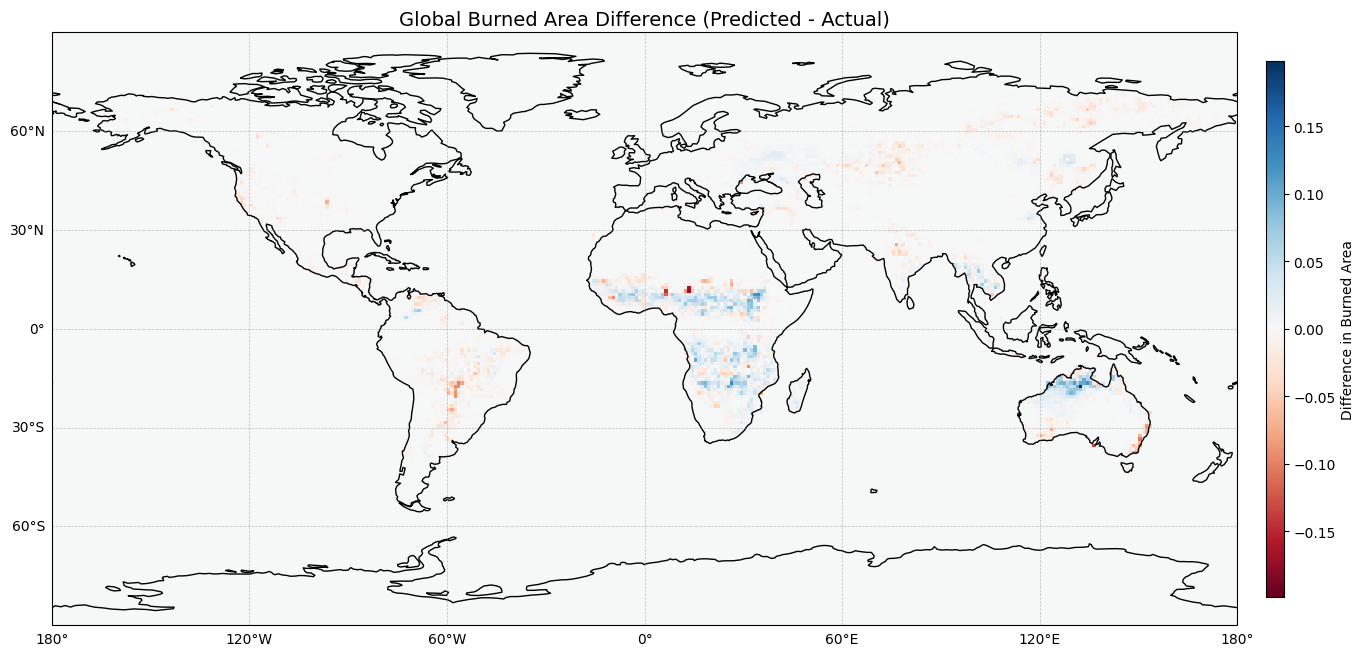

In [16]:
def plot_burned_area_difference_map(input_data, preds_array):
    # Extract latitude and longitude
    lats = input_data.latitude.values
    lons = input_data.longitude.values

    # Get actual and predicted burned area data
    actual = input_data["fcci_ba"].values
    predicted = preds_array.squeeze(1)  # Shape should match (time, lat, lon)

    # Replace NaNs with 0 for clean visualization
    actual = np.nan_to_num(actual)
    predicted = np.nan_to_num(predicted)

    # Compute the difference over time
    diff = predicted - actual  # Shape: (time, lat, lon)
    diff_sum = np.sum(diff, axis=0)  # Sum across time dimension

    # Set up the map
    fig = plt.figure(figsize=(15, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()

    # Add features
    ax.coastlines()  # Keep coastlines
    ax.add_feature(cfeature.LAND, alpha=0.3)  # Land shading without edge border

    # Optional: Keep or remove gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    # Plot the difference map
    mesh = ax.pcolormesh(
        lons,
        lats,
        diff_sum,
        cmap="RdBu",
        transform=ccrs.PlateCarree(),
        shading="auto",
        vmin=-np.max(np.abs(diff_sum)),
        vmax=np.max(np.abs(diff_sum))
    )

    # Add title
    plt.title("Global Burned Area Difference (Predicted - Actual)", fontsize=14)

    # Add colorbar on the right side
    cbar = plt.colorbar(
        mesh,
        orientation="vertical",
        pad=0.02,
        aspect=30,
        shrink=0.8
    )
    cbar.set_label("Difference in Burned Area")

    plt.tight_layout()
    plt.show()


# Example call (assuming input_data and preds_array are defined correctly)
plot_burned_area_difference_map(input_data, preds_array)


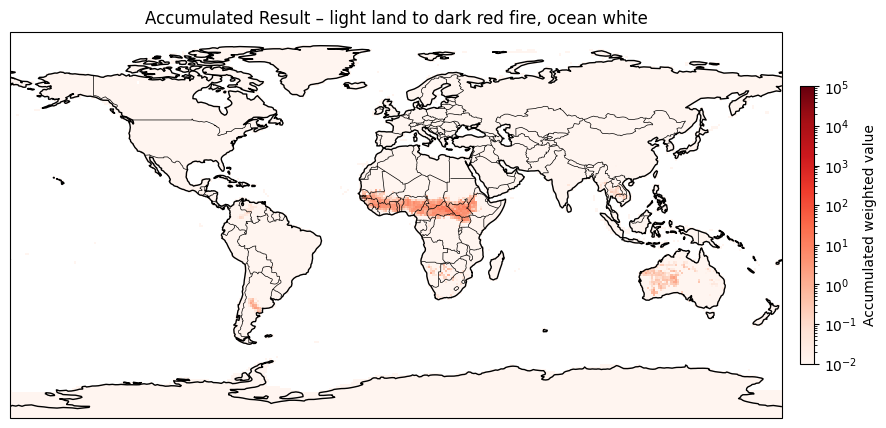

In [17]:
# ─── (Re)compute or load your 2D result ────────────────────────────────────────
mask_path = "/ceph/hpc/home/ciangottinid/ML4Fires/mask.nc"
df_mask   = xr.open_dataset(mask_path)
df1       = xr.open_zarr(data_path)

# pick the first ML variable if needed
if isinstance(df1, xr.Dataset):
    df1 = df1[list(df1.data_vars)[0]]

# accumulate weighted sums over mask classes
k = xr.zeros_like(df1)
for c in df_mask.cl.values:
    msl = df_mask["basis_regions"].isel(cl=c)
    a1, m1 = xr.align(df1, msl, join="inner")
    w = (a1 * m1).sum().compute().item()
    k += (a1 * m1) * w
k = k.compute()
k2d = k.isel(time=0)  # pick one time slice

# ─── build a land/ocean mask ───────────────────────────────────────────────────
land_mask = (df_mask["basis_regions"].sum(dim="cl") > 0)
_, land_mask = xr.align(k2d, land_mask, join="inner")
land_mask_arr = land_mask.values

# ─── prepare data: ocean=NaN, floor tiny lands to vmin ─────────────────────────
data2d = k2d.values.astype(float)
vmin, vmax = 0.01, 1e5

# ocean stays NaN → white
data2d_masked = np.full_like(data2d, np.nan, dtype=float)
# fill land values
data2d_masked[land_mask_arr] = data2d[land_mask_arr]
# any land below vmin → set to vmin (lightest red)
low_land = land_mask_arr & (data2d_masked < vmin)
data2d_masked[low_land] = vmin

# ─── choose Reds colormap ─────────────────────────────────────────────────────
cmap = plt.cm.Reds.copy()      # sequential reds: light→dark
cmap.set_bad("white")          # ocean (NaN) = white
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

# ─── plot on world map ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 6))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

lon2d, lat2d = np.meshgrid(k2d.longitude, k2d.latitude)
im = ax.pcolormesh(
    lon2d, lat2d, data2d_masked,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto"
)

cbar = plt.colorbar(im, ax=ax, orientation="vertical", shrink=0.6, pad=0.02)
cbar.set_label("Accumulated weighted value")
ax.set_title("Accumulated Result – light land to dark red fire, ocean white")
plt.show()
